# 06 — Backtesting a Manual Rule-Based Strategy

This notebook introduces the cost-aware backtesting engine
(`quantlab.backtest`) and runs the human-designed baseline strategy
(`quantlab.strategies.ManualRuleStrategy`) against buy-and-hold.

**Setup:** trade a single symbol (MSFT), $100,000 starting cash, position
size capped at the number of shares affordable at the window's first price
(unlevered, so strategy and benchmark are directly comparable). Every fill
pays $1.00 commission and 0.1% market impact. Train period 2016–2019 (where
the thresholds were eyeballed), test period 2020–2023 (untouched).

The strategy votes three indicators from notebook 04 — Bollinger %B,
momentum, and price/SMA — and takes a long/short position when at least two
agree.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from quantlab.backtest import affordable_shares, positions_to_trades, run_backtest, summarize
from quantlab.backtest.engine import buy_and_hold_benchmark
from quantlab.data import load_prices
from quantlab.strategies import ManualRuleStrategy

plt.rcParams["figure.figsize"] = (11, 5)

SYMBOL = "MSFT"
TRAIN = slice("2016-01-01", "2019-12-31")
TEST = slice("2020-01-01", "2023-12-31")
START_CASH = 100_000
COMMISSION = 1.00
IMPACT = 0.001

prices = load_prices(SYMBOL, "2016-01-01", "2023-12-31")[SYMBOL]

## The backtest engine in one cell

`run_backtest` walks the price series day by day: buys fill at
`price × (1 + impact)`, sells at `price × (1 − impact)`, every trade pays
commission, and the portfolio is marked to market at each close. It is
unit-tested against hand-computed cases in
[`tests/test_backtest.py`](../tests/test_backtest.py).

In [2]:
def evaluate(positions: pd.Series, window_prices: pd.Series, name: str):
    max_shares = affordable_shares(window_prices, START_CASH)
    trades = positions_to_trades(positions, max_shares=max_shares)
    result = run_backtest(
        trades, window_prices, start_cash=START_CASH, commission=COMMISSION, impact=IMPACT
    )
    return result["value"], summarize(result["value"], name)


def benchmark(window_prices: pd.Series) -> pd.Series:
    shares = affordable_shares(window_prices, START_CASH)
    return buy_and_hold_benchmark(
        window_prices, START_CASH, shares, COMMISSION, IMPACT
    )["value"]


strategy = ManualRuleStrategy()

## In-sample (2016–2019)

In [3]:
train_prices = prices.loc[TRAIN]
manual_train, manual_train_stats = evaluate(
    strategy.positions(train_prices), train_prices, "manual (in-sample)"
)
bench_train = benchmark(train_prices)
pd.DataFrame(
    [manual_train_stats, summarize(bench_train, "buy & hold (in-sample)")]
).round(4)

,cumulative_return,avg_daily_return,daily_volatility,sharpe_ratio,max_drawdown,final_value
manual (in-sample),0.5766,0.0007,0.0225,0.4965,-0.5703,157657.9199
buy & hold (in-sample),2.1223,0.0012,0.0138,1.4118,-0.1823,311917.0480


## Out-of-sample (2020–2023)

In [4]:
test_prices = prices.loc[TEST]
positions_test = strategy.positions(test_prices)
manual_test, manual_test_stats = evaluate(positions_test, test_prices, "manual (out-of-sample)")
bench_test = benchmark(test_prices)
pd.DataFrame(
    [manual_test_stats, summarize(bench_test, "buy & hold (out-of-sample)")]
).round(4)

,cumulative_return,avg_daily_return,daily_volatility,sharpe_ratio,max_drawdown,final_value
manual (out-of-sample),0.3305,0.0007,0.0290,0.3844,-0.4538,133045.5495
buy & hold (out-of-sample),1.4296,0.0011,0.0205,0.8458,-0.3715,242713.6608


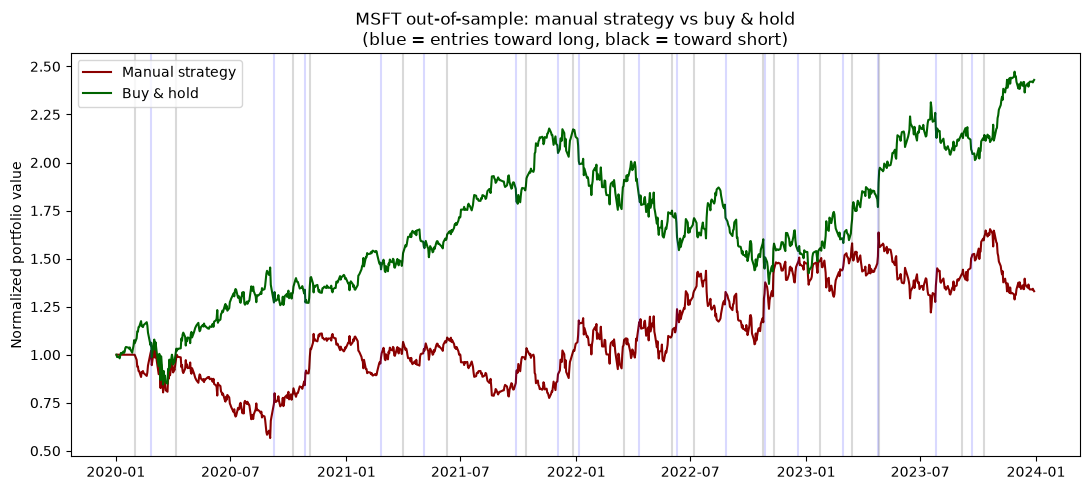

In [5]:
fig, ax = plt.subplots()
ax.plot(manual_test / manual_test.iloc[0], label="Manual strategy", color="darkred")
ax.plot(bench_test / bench_test.iloc[0], label="Buy & hold", color="darkgreen")

longs = positions_test.diff() > 0
shorts = positions_test.diff() < 0
for date in positions_test.index[longs]:
    ax.axvline(date, color="blue", alpha=0.15)
for date in positions_test.index[shorts]:
    ax.axvline(date, color="black", alpha=0.15)
ax.set_title(f"{SYMBOL} out-of-sample: manual strategy vs buy & hold\n(blue = entries toward long, black = toward short)")
ax.set_ylabel("Normalized portfolio value")
ax.legend()
plt.tight_layout()
plt.savefig("../docs/img/06_manual_vs_benchmark.png", dpi=120)
plt.show()

## How much do costs matter?

In [6]:
cost_grid = []
test_shares = affordable_shares(test_prices, START_CASH)
for impact in [0.0, 0.001, 0.005, 0.01]:
    trades = positions_to_trades(positions_test, test_shares)
    values = run_backtest(trades, test_prices, START_CASH, COMMISSION, impact)["value"]
    cost_grid.append(summarize(values, f"impact={impact:.3f}"))
pd.DataFrame(cost_grid).round(4)

,cumulative_return,avg_daily_return,daily_volatility,sharpe_ratio,max_drawdown,final_value
impact=0.000,0.4456,0.0008,0.0282,0.4290,-0.4504,144561.5183
impact=0.001,0.3305,0.0007,0.0290,0.3844,-0.4538,133045.5495
impact=0.005,-0.1302,0.0004,0.0336,0.1996,-0.4674,86981.6744
impact=0.010,-0.7060,-0.0000,0.0491,-0.0062,-0.7511,29401.8305


## Takeaways

- The manual strategy trades the mean-reversion edge found in notebook 04.
  Whether it beats buy-and-hold out-of-sample depends heavily on the regime:
  a strong bull market is very hard for a partially-flat strategy to beat.
- **Costs eat weak edges.** The impact sweep shows performance degrading
  monotonically with slippage; any strategy evaluated with zero costs should
  be assumed broken.
- This is the honest baseline. Notebook 07 asks whether a machine-learned
  strategy on the *same features, same costs, same discipline* can do better.

## Ceiling: theoretically optimal strategy

For an unattainable upper bound, `theoretically_optimal_trades` peeks one day ahead (zero costs). Compare it to manual rules in the research report; it is not a competing live strategy.


In [ ]:
from quantlab.strategies import theoretically_optimal_trades
tos_trades = theoretically_optimal_trades(test_prices, max_shares=MAX_SHARES)
tos_values = run_backtest(tos_trades, test_prices, START_CASH, commission=0.0, impact=0.0)["value"]
print(summarize(tos_values, "TOS (zero cost)"))
